## <h3 align="center"> __Johns Hopkins University__</h3>
## <h3 align="center">__Whiting School of Engineering__</h3>
## <h3 align="center">__Engineering for Professionals__</h3>
## <h3 align="center">__685.801 Data Science: Independent Study__</h3>
## <h3 align="center">__Backbone Latent Space Analysis__</h3>

---

- **Purpose:** Load selected trained checkpoints, extract backbone feature spaces, and train 2D autoencoders to visualize clustering structure.
- **Primary use case:** Compare JE ConvNeXt latent spaces against standard ConvNeXt backbone feature spaces.
- **User input:** Provide a list of `.pth` filenames in the model-selection cell.
- **Outputs:** In-notebook visualizations only; nothing is saved to disk.
- **How to use:**
  1. Update `SELECTED_MODEL_FILES` with the checkpoint filenames you want to analyze.
  2. Choose the JE representation source with `JE_FEATURE_SOURCE` if needed.
  3. Run the notebook top to bottom.
  4. Review the per-model reconstruction losses, 2D latent scatter plots, and centroid-separation summaries.

---

In [1]:
%pip install numpy pandas scipy seaborn matplotlib scikit-learn statsmodels kagglehub torch torchvision torchao torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 67.1 MB/s eta 0:00:00


In [2]:
# Environment check
import sys, platform
print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())
try:
    import numpy as np, pandas as pd, seaborn, matplotlib, sklearn, torch, torchvision, kagglehub
    print(f'numpy:      {np.__version__}')
    print(f'pandas:     {pd.__version__}')
    print(f'seaborn:    {seaborn.__version__}')
    print(f'matplotlib: {matplotlib.__version__}')
    print(f'sklearn:    {sklearn.__version__}')
    print(f'torch:      {torch.__version__}')
    print(f'torchvision:{torchvision.__version__}')
except Exception as exc:
    print('Optional packages missing or version check failed:', exc)
    print('Use the command in the cell above to install necessary packages.')

Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
numpy:      2.0.2
pandas:     2.2.2
seaborn:    0.13.2
matplotlib: 3.10.0
sklearn:    1.6.1
torch:      2.11.0+cu128
torchvision:0.26.0+cu128


In [3]:
import os
import subprocess
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    drive = None
    IN_COLAB = False

REPO_URL = "https://github.com/ddimpfel/JHU_IS_26.git"
REPO_NAME = REPO_URL.split("/")[-1].replace(".git", "")

if IN_COLAB:
    drive.mount('/content/drive')
    repo_root = Path('/content') / REPO_NAME
    if not repo_root.exists():
        subprocess.run(['git', 'clone', REPO_URL], check=True)
    CURRENT_WORK_DIR = repo_root
    os.chdir(CURRENT_WORK_DIR)
    RESULTS_DIR = Path('/content/drive/MyDrive/is26_models/joint_embedding_results')
else:
    CURRENT_WORK_DIR = Path.cwd()

Mounted at /content/drive


In [4]:
raise Exception("You must manually add the model files to continue. Upload them to JHU_IS_26/models/ in Colab.")

Exception: You must manually add the model files to continue. Upload them to JHU_IS_26/models/ in Colab.

In [5]:
import re
import random
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from IPython.display import display
from PIL import Image
from sklearn.manifold import trustworthiness
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.nn import CrossEntropyLoss
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset, TensorDataset

from continual_learning import CILComputerVisionModel
from gre_model_base import GeneralistRouterExperts
from joint_embedding import JointEmbeddingModule

## Runtime Setup

In [6]:
if str(CURRENT_WORK_DIR) not in sys.path:
    sys.path.insert(0, str(CURRENT_WORK_DIR))

MODELS_DIR = CURRENT_WORK_DIR / 'models'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'IN_COLAB={IN_COLAB}')
print(f'CURRENT_WORK_DIR={CURRENT_WORK_DIR}')
print(f'MODELS_DIR={MODELS_DIR.resolve()}')
print(f'Using device: {device}')

IN_COLAB=True
CURRENT_WORK_DIR=/content/JHU_IS_26
MODELS_DIR=/content/JHU_IS_26/models
Using device: cuda


## Config

In [7]:
SEED = 7
TOTAL_CLASSES = 9
IMG_SIZE = 224
BATCH_SIZE = 64 if IN_COLAB else 16
NUM_WORKERS = 0
PIN_MEMORY = bool(IN_COLAB)
PERSIST_WORKERS = False

NUM_EXPERTS = 6
HIDDEN_EXPERT_SIZE = 128
DROPOUT = 0.1
TOP_K = 2
LAMBDA_AUX = 0.05
TFE_D_MODEL = 32
TFE_NHEAD = 4

JE_EMBEDDING_DIM = 256
JE_PROJECTION_DIM = 256
JE_TEMPERATURE = 0.07
JE_FEATURE_SOURCE = 'projections'  # 'embeddings' or 'backbone_features'
ANALYSIS_SPLIT = 'test'  # 'train'
FEATURE_SAMPLE_LIMIT = None  # 4000 for quicker Colab runs
AUTOENCODER_HIDDEN_DIM = 256
AUTOENCODER_LATENT_DIM = 2
AUTOENCODER_EPOCHS = 80
AUTOENCODER_BATCH_SIZE = 256 if IN_COLAB else 64
AUTOENCODER_LR = 1e-3
AUTOENCODER_WEIGHT_DECAY = 1e-5

SELECTED_MODEL_FILES = [
    'ConvNeXt + MLP Router + MLP Experts_2026-06-28.pth',
    'JE ConvNeXt Tiny + MLP Router + MLP Experts_2026-07-15.pth',
    'ConvNeXt + Layered Router + Transformer Experts_2026-06-28.pth',
    'JE ConvNeXt Tiny + Layered Router + Transformer Experts_2026-07-15.pth',

    'MobileNet + MLP Router + MLP Experts_2026-06-28.pth',
    'JE MobileNet Small + MLP Router + MLP Experts_2026-07-15.pth',
    'MobileNet + Layered Router + Transformer Experts_2026-06-28.pth',
    'JE MobileNet Small + Layered Router + Transformer Experts_2026-07-15.pth',
]
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np_rng = np.random.default_rng(seed=SEED)
tor_gen = torch.Generator(device='cpu').manual_seed(SEED)

if not SELECTED_MODEL_FILES:
    raise ValueError('Populate SELECTED_MODEL_FILES with at least one checkpoint filename before continuing.')

## Data Loading

In [8]:
GTSRB_DATASET_NAME = 'meowmeowmeowmeowmeow/gtsrb-german-traffic-sign'
csv_paths = {
    'train.csv': None,
    'test.csv': None,
    'meta.csv': None,
}

download_dir = Path(kagglehub.dataset_download(GTSRB_DATASET_NAME))
for csv in download_dir.rglob('*.csv'):
    if csv.name.lower() in csv_paths:
        csv_paths[csv.name.lower()] = csv

train_csv = pd.read_csv(str(csv_paths['train.csv']))
train_df, _ = train_test_split(
    train_csv,
    test_size=0.2,
    shuffle=True,
    stratify=train_csv.ClassId,
    random_state=SEED,
)
test_df = pd.read_csv(str(csv_paths['test.csv']))

prohibitory_sign_classes = [i for i in range(1, 11)]
prohibitory_sign_classes.remove(6)

analysis_df = train_df if ANALYSIS_SPLIT == 'train' else test_df
analysis_df = analysis_df[analysis_df.ClassId.isin(prohibitory_sign_classes)].reset_index(drop=True)
class_mapping = {raw_id: i for i, raw_id in enumerate(sorted(prohibitory_sign_classes))}
signnames_url = 'https://raw.githubusercontent.com/georgesung/traffic_sign_classification_german/master/signnames.csv'
signnames_path = CURRENT_WORK_DIR / 'signnames.csv'
if not signnames_path.exists():
    import urllib.request
    urllib.request.urlretrieve(signnames_url, signnames_path)
class_names = pd.read_csv(signnames_path)
class_name_lookup = {
    class_mapping[row.ClassId]: row.SignName
    for row in class_names.itertuples() if row.ClassId in class_mapping
}

print('Kaggle dataset directory:', download_dir)
print(f'Analysis split: {ANALYSIS_SPLIT}')
print(f'Examples in split: {len(analysis_df)}')

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Kaggle dataset directory: /kaggle/input/gtsrb-german-traffic-sign
Analysis split: test
Examples in split: 5250


In [9]:
class TrafficSignDataset(Dataset):
    def __init__(self, data_dir, image_file_paths, targets, transformer, class_mapping):
        if len(targets) != len(image_file_paths):
            raise AssertionError('Must have equal number of labels to images')
        self.data_dir = data_dir
        self.image_file_paths = list(image_file_paths)
        self.targets = list(targets)
        self.transformer = transformer
        self.class_mapping = class_mapping

    def __len__(self):
        return len(self.image_file_paths)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.image_file_paths[idx])
        image = Image.open(img_path).convert('RGB')
        transformed_img = self.transformer(image)
        label = self.class_mapping[self.targets[idx]]
        target = {'label': torch.tensor(label, dtype=torch.long)}
        return transformed_img, target, str(img_path)


def collate_data(return_values):
    images = [item[0] for item in return_values]
    targets = [item[1] for item in return_values]
    paths = [item[2] for item in return_values]
    return images, targets, paths


transform_pipeline = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

analysis_dataset = TrafficSignDataset(
    download_dir,
    analysis_df.Path,
    analysis_df.ClassId,
    transform_pipeline,
    class_mapping,
)

analysis_dataloader = DataLoader(
    analysis_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=collate_data,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSIST_WORKERS,
    generator=tor_gen,
)

print(f'Analysis dataloader batches: {len(analysis_dataloader)}')

Analysis dataloader batches: 83


## Model Reconstruction

In [10]:
class MobileNetGeneralist(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base_model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        self.backbone = base_model.features
        self.pool = base_model.avgpool
        self.out_channels = base_model.classifier[0].in_features
        self.classifier = nn.Sequential(
            nn.Linear(self.out_channels, num_classes),
            nn.LayerNorm(num_classes),
        )

    def forward(self, x, return_features=False):
        x = self.backbone(x)
        features = self.pool(x).flatten(1)
        logits = self.classifier(features)
        if return_features:
            return logits, features
        return logits


class ConvNeXtTinyGeneralist(nn.Module):
    def __init__(self, num_classes, weights=models.ConvNeXt_Tiny_Weights.DEFAULT, dropout=0.1):
        super().__init__()
        base_model = models.convnext_tiny(weights=weights)
        self.backbone = base_model.features
        self.pool = base_model.avgpool
        self.out_channels = base_model.classifier[2].in_features
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.out_channels),
            nn.Dropout(dropout),
            nn.Linear(self.out_channels, num_classes),
        )

    def forward(self, x, return_features=False):
        x = self.backbone(x)
        features = self.pool(x).flatten(1)
        logits = self.classifier(features)
        if return_features:
            return logits, features
        return logits


class MlpRouter(nn.Module):
    def __init__(self, input_size, num_experts):
        super().__init__()
        self.num_experts = num_experts
        self.gating = nn.Linear(input_size, num_experts, bias=False)

    def forward(self, x):
        logits = self.gating(x)
        if self.training:
            logits = logits + torch.randn_like(logits) * (1.0 / self.num_experts)
        return logits


class LayeredRouter(nn.Module):
    def __init__(self, input_size, num_experts):
        super().__init__()
        self.num_experts = num_experts
        self.ff1 = nn.Linear(input_size, input_size * 2)
        self.ff2 = nn.Linear(input_size * 2, num_experts, bias=False)

    def forward(self, x):
        logits = self.ff2(self.ff1(x))
        if self.training:
            logits = logits + torch.randn_like(logits) * (1.0 / self.num_experts)
        return logits


class MlpExpert(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.1):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, output_size),
        )

    def forward(self, x):
        return self.network(x)


class TransformerExpert(nn.Module):
    def __init__(self, in_features, d_model, nhead, output_size):
        super().__init__()
        if in_features % d_model != 0:
            raise ValueError('d_model must perfectly divide in_features')
        self.num_patches = in_features // d_model
        self.d_model = d_model
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, d_model))
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True),
            num_layers=1,
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, output_size),
        )

    def forward(self, x):
        batch_size = x.shape[0]
        x = x.view(batch_size, self.num_patches, self.d_model)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1) + self.pos_embed
        x = self.transformer(x)
        cls_output = x[:, 0, :]
        return self.classifier(cls_output)


class ResidualGatedMlpExpert(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.LayerNorm(input_size),
            nn.Linear(input_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.block1 = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, hidden_size * 2),
            nn.GLU(dim=1),
            nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, hidden_size * 2),
            nn.GLU(dim=1),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.input_proj(x)
        x = x + self.block1(x)
        x = x + self.block2(x)
        return self.classifier(x)


class JointEmbeddingRouterExperts(GeneralistRouterExperts):
    def __init__(self, *args, feature_key='projections', **kwargs):
        super().__init__(*args, **kwargs)
        self.feature_key = feature_key
        self._last_joint_embedding_outputs = None

    def reset_routing_state(self):
        super().reset_routing_state()
        self._last_joint_embedding_outputs = None

    def get_joint_embedding_loss(self, labels):
        if self._last_joint_embedding_outputs is None:
            param = next(self.parameters())
            return torch.zeros((), device=param.device, dtype=param.dtype)

        if self.feature_key == 'embeddings':
            return self.generalist.compute_contrastive_loss(
                labels=labels,
                embeddings=self._last_joint_embedding_outputs['embeddings'],
            )

        return self.generalist.compute_contrastive_loss(
            labels=labels,
            projections=self._last_joint_embedding_outputs['projections'],
        )

    def forward(self, x):
        encoded = self.generalist.backbone.encode(x)
        generalist_logits = encoded['logits']
        features = encoded[self.feature_key]
        if features.ndim != 2:
            features = torch.flatten(features, 1)

        router_logits = self.router(features)
        router_probs = F.softmax(router_logits, dim=1)
        topk_probs, topk_indices = torch.topk(router_probs, k=self.k, dim=1)
        topk_weights = topk_probs / topk_probs.sum(dim=1, keepdim=True).clamp_min(1e-8)

        experts_logits = torch.zeros_like(generalist_logits, device=features.device, dtype=features.dtype)
        for expert_idx, expert in enumerate(self.experts):
            selected_rows, selected_slots = torch.where(topk_indices == expert_idx)
            if selected_rows.numel() == 0:
                continue
            expert_features = features[selected_rows]
            expert_logits = expert(expert_features)
            expert_weights = topk_weights[selected_rows, selected_slots].unsqueeze(1)
            experts_logits[selected_rows] += expert_logits * expert_weights

        self._last_router_probs = router_probs.detach()
        self._last_topk_indices = topk_indices.detach()
        self._last_aux_loss = self._compute_auxiliary_loss(router_probs, topk_indices)
        self._last_joint_embedding_outputs = {
            key: value
            for key, value in encoded.items()
            if isinstance(value, torch.Tensor)
        }
        return (generalist_logits + experts_logits) / self.temperature


def strip_trailing_date_suffix(value):
    return re.sub(r'_\d{4}-\d{2}-\d{2}$', '', str(value))


def extract_model_name(checkpoint_path: Path):
    return strip_trailing_date_suffix(checkpoint_path.stem)


def build_expert_factory(expert_name, generalist_out_dim):
    def expert_factory():
        if expert_name == 'MLP Experts':
            return MlpExpert(
                input_size=generalist_out_dim,
                hidden_size=HIDDEN_EXPERT_SIZE,
                output_size=TOTAL_CLASSES,
                dropout=DROPOUT,
            )
        if expert_name == 'Transformer Experts':
            return TransformerExpert(
                in_features=generalist_out_dim,
                d_model=TFE_D_MODEL,
                nhead=TFE_NHEAD,
                output_size=TOTAL_CLASSES,
            )
        if expert_name == 'ResMLP Experts':
            return ResidualGatedMlpExpert(
                input_size=generalist_out_dim,
                hidden_size=HIDDEN_EXPERT_SIZE,
                output_size=TOTAL_CLASSES,
                dropout=DROPOUT,
            )
        raise KeyError(f'Unknown expert: {expert_name}')

    return expert_factory


def build_model_from_name(model_name: str):
    parts = str(model_name).split(' + ')
    if len(parts) != 3:
        raise ValueError(f'Expected model name in the form Generalist + Router + Expert, got: {model_name}')

    generalist_name, router_name, expert_name = parts

    if generalist_name == 'MobileNet':
        generalist = MobileNetGeneralist(num_classes=TOTAL_CLASSES)
        generalist_out_dim = generalist.out_channels
        router_cls = MlpRouter if router_name == 'MLP Router' else LayeredRouter
        router = router_cls(input_size=generalist_out_dim, num_experts=NUM_EXPERTS)
        return GeneralistRouterExperts(
            generalist=generalist,
            router=router,
            expert_factory=build_expert_factory(expert_name, generalist_out_dim),
            num_experts=NUM_EXPERTS,
            num_classes=TOTAL_CLASSES,
            k=TOP_K,
            lambda_aux=LAMBDA_AUX,
        )

    if generalist_name == 'ConvNeXt':
        generalist = ConvNeXtTinyGeneralist(num_classes=TOTAL_CLASSES)
        generalist_out_dim = generalist.out_channels
        router_cls = MlpRouter if router_name == 'MLP Router' else LayeredRouter
        router = router_cls(input_size=generalist_out_dim, num_experts=NUM_EXPERTS)
        return GeneralistRouterExperts(
            generalist=generalist,
            router=router,
            expert_factory=build_expert_factory(expert_name, generalist_out_dim),
            num_experts=NUM_EXPERTS,
            num_classes=TOTAL_CLASSES,
            k=TOP_K,
            lambda_aux=LAMBDA_AUX,
        )

    if generalist_name == 'JE MobileNet Small':
        generalist = JointEmbeddingModule(
            num_classes=TOTAL_CLASSES,
            backbone='mobilenet_v3_small',
            embedding_dim=JE_EMBEDDING_DIM,
            projection_dim=JE_PROJECTION_DIM,
            pretrained=True,
            temperature=JE_TEMPERATURE,
        )
        generalist_out_dim = JE_PROJECTION_DIM if JE_FEATURE_SOURCE in {'projections', 'embeddings'} else generalist.backbone.backbone_feature_dim
        if JE_FEATURE_SOURCE == 'embeddings':
            generalist_out_dim = JE_EMBEDDING_DIM
        elif JE_FEATURE_SOURCE == 'backbone_features':
            generalist_out_dim = generalist.backbone.backbone_feature_dim
        router_cls = MlpRouter if router_name == 'MLP Router' else LayeredRouter
        router = router_cls(input_size=generalist_out_dim, num_experts=NUM_EXPERTS)
        return JointEmbeddingRouterExperts(
            generalist=generalist,
            router=router,
            expert_factory=build_expert_factory(expert_name, generalist_out_dim),
            num_experts=NUM_EXPERTS,
            num_classes=TOTAL_CLASSES,
            k=TOP_K,
            lambda_aux=LAMBDA_AUX,
            feature_key=JE_FEATURE_SOURCE if JE_FEATURE_SOURCE in {'projections', 'embeddings'} else 'projections',
        )

    if generalist_name == 'JE ConvNeXt Tiny':
        generalist = JointEmbeddingModule(
            num_classes=TOTAL_CLASSES,
            backbone='convnext_tiny',
            embedding_dim=JE_EMBEDDING_DIM,
            projection_dim=JE_PROJECTION_DIM,
            pretrained=True,
            temperature=JE_TEMPERATURE,
        )
        generalist_out_dim = JE_PROJECTION_DIM if JE_FEATURE_SOURCE in {'projections', 'embeddings'} else generalist.backbone.backbone_feature_dim
        if JE_FEATURE_SOURCE == 'embeddings':
            generalist_out_dim = JE_EMBEDDING_DIM
        elif JE_FEATURE_SOURCE == 'backbone_features':
            generalist_out_dim = generalist.backbone.backbone_feature_dim
        router_cls = MlpRouter if router_name == 'MLP Router' else LayeredRouter
        router = router_cls(input_size=generalist_out_dim, num_experts=NUM_EXPERTS)
        return JointEmbeddingRouterExperts(
            generalist=generalist,
            router=router,
            expert_factory=build_expert_factory(expert_name, generalist_out_dim),
            num_experts=NUM_EXPERTS,
            num_classes=TOTAL_CLASSES,
            k=TOP_K,
            lambda_aux=LAMBDA_AUX,
            feature_key=JE_FEATURE_SOURCE if JE_FEATURE_SOURCE in {'projections', 'embeddings'} else 'projections',
        )

    raise KeyError(f'Unsupported generalist name: {generalist_name}')

## Feature Extraction

In [11]:
def normalize_backbone_label(model_name: str):
    lowered = str(model_name).lower()
    if lowered.startswith('je convnext'):
        return 'JE ConvNeXt'
    if lowered.startswith('convnext'):
        return 'ConvNeXt'
    if lowered.startswith('je mobilenet'):
        return 'JE MobileNet'
    if lowered.startswith('mobilenet'):
        return 'MobileNet'
    return 'Other'


def resolve_selected_checkpoints(model_dir: Path, selected_filenames: list[str]):
    resolved = []
    missing = []
    for filename in selected_filenames:
        candidate = model_dir / filename
        if candidate.exists():
            resolved.append(candidate)
        else:
            missing.append(filename)
    if missing:
        raise FileNotFoundError(f'Missing checkpoint files in {model_dir.resolve()}: {missing}')
    return resolved


def extract_backbone_features(model: nn.Module, images: torch.Tensor):
    if isinstance(model, JointEmbeddingRouterExperts):
        encoded = model.generalist.backbone.encode(images)
        if JE_FEATURE_SOURCE not in encoded:
            raise KeyError(f'JE_FEATURE_SOURCE={JE_FEATURE_SOURCE!r} not available. Valid keys: {list(encoded.keys())}')
        return encoded[JE_FEATURE_SOURCE], f'JE {JE_FEATURE_SOURCE}'

    if isinstance(model, GeneralistRouterExperts):
        _, features = model.generalist(images, return_features=True)
        if features.ndim != 2:
            features = torch.flatten(features, 1)
        return features, 'Backbone Features'

    raise TypeError(f'Unsupported model type for feature extraction: {type(model).__name__}')


def collect_model_feature_table(checkpoint_paths):
    feature_records = []
    raw_feature_bundles = {}

    for checkpoint_path in checkpoint_paths:
        model_name = extract_model_name(checkpoint_path)
        model_instance = build_model_from_name(model_name)
        wrapper = CILComputerVisionModel.load(model_instance, filename=str(checkpoint_path), device=device)
        model = wrapper.model.to(device)
        model.eval()

        features_list = []
        label_list = []
        path_list = []
        feature_source = None

        with torch.no_grad():
            for images, labels, paths in analysis_dataloader:
                images = torch.stack(images).to(device)
                y_true = torch.tensor([label['label'] for label in labels], dtype=torch.long, device=device)
                batch_features, feature_source = extract_backbone_features(model, images)
                features_list.append(batch_features.detach().cpu())
                label_list.append(y_true.detach().cpu())
                path_list.extend(paths)

        features = torch.cat(features_list, dim=0).numpy()
        labels = torch.cat(label_list, dim=0).numpy()

        if FEATURE_SAMPLE_LIMIT is not None and len(features) > FEATURE_SAMPLE_LIMIT:
            sample_indices = np_rng.choice(len(features), size=FEATURE_SAMPLE_LIMIT, replace=False)
            features = features[sample_indices]
            labels = labels[sample_indices]
            path_list = [path_list[index] for index in sample_indices]

        raw_feature_bundles[model_name] = {
            'features': features,
            'labels': labels,
            'paths': path_list,
            'feature_source': feature_source,
            'backbone': normalize_backbone_label(model_name),
        }

        feature_records.append({
            'Model': model_name,
            'Checkpoint': checkpoint_path.name,
            'Backbone': normalize_backbone_label(model_name),
            'Feature Source': feature_source,
            'Feature Dimension': features.shape[1],
            'Sample Count': len(features),
        })

    return pd.DataFrame(feature_records), raw_feature_bundles

In [12]:
selected_checkpoint_paths = resolve_selected_checkpoints(MODELS_DIR, SELECTED_MODEL_FILES)
feature_summary_df, feature_bundles = collect_model_feature_table(selected_checkpoint_paths)
display(feature_summary_df)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:08<00:00, 14.3MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 228MB/s]


,Model,Checkpoint,Backbone,Feature Source,Feature Dimension,Sample Count
0,ConvNeXt + MLP Router + MLP Experts,ConvNeXt + MLP Router + MLP Experts_2026-06-28...,ConvNeXt,Backbone Features,768,5250
1,JE ConvNeXt Tiny + MLP Router + MLP Experts,JE ConvNeXt Tiny + MLP Router + MLP Experts_20...,JE ConvNeXt,JE projections,256,5250
2,ConvNeXt + Layered Router + Transformer Experts,ConvNeXt + Layered Router + Transformer Expert...,ConvNeXt,Backbone Features,768,5250
3,JE ConvNeXt Tiny + Layered Router + Transforme...,JE ConvNeXt Tiny + Layered Router + Transforme...,JE ConvNeXt,JE projections,256,5250
4,MobileNet + MLP Router + MLP Experts,MobileNet + MLP Router + MLP Experts_2026-06-2...,MobileNet,Backbone Features,576,5250
5,JE MobileNet Small + MLP Router + MLP Experts,JE MobileNet Small + MLP Router + MLP Experts_...,JE MobileNet,JE projections,256,5250
6,MobileNet + Layered Router + Transformer Experts,MobileNet + Layered Router + Transformer Exper...,MobileNet,Backbone Features,576,5250
7,JE MobileNet Small + Layered Router + Transfor...,JE MobileNet Small + Layered Router + Transfor...,JE MobileNet,JE projections,256,5250


## Autoencoder Projection

In [13]:
class ProjectionAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, encoded_dim=2):
        super().__init__()
        bottleneck_hidden_dim = min(hidden_dim, max(64, input_dim // 2))
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, bottleneck_hidden_dim),
            nn.GELU(),
            nn.Linear(bottleneck_hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, encoded_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoded_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, bottleneck_hidden_dim),
            nn.GELU(),
            nn.Linear(bottleneck_hidden_dim, input_dim),
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction, latent


def fit_autoencoder(features: np.ndarray):
    scaler = StandardScaler()
    standardized_features = scaler.fit_transform(features)
    feature_tensor = torch.tensor(standardized_features, dtype=torch.float32)
    dataset = TensorDataset(feature_tensor)
    loader = DataLoader(dataset, batch_size=AUTOENCODER_BATCH_SIZE, shuffle=True, generator=tor_gen)

    model = ProjectionAutoencoder(
        input_dim=feature_tensor.shape[1],
        hidden_dim=AUTOENCODER_HIDDEN_DIM,
        encoded_dim=AUTOENCODER_LATENT_DIM,
    ).to(device)
    optimizer = AdamW(model.parameters(), lr=AUTOENCODER_LR, weight_decay=AUTOENCODER_WEIGHT_DECAY)
    loss_fn = nn.MSELoss()
    loss_history = []

    model.train()
    for _ in range(AUTOENCODER_EPOCHS):
        epoch_loss = 0.0
        for (batch_features,) in loader:
            batch_features = batch_features.to(device)
            optimizer.zero_grad(set_to_none=True)
            reconstruction, _ = model(batch_features)
            loss = loss_fn(reconstruction, batch_features)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.detach().item() * batch_features.size(0)
        loss_history.append(epoch_loss / len(dataset))

    model.eval()
    with torch.no_grad():
        _, latent = model(feature_tensor.to(device))
    return {
        'scaler': scaler,
        'autoencoder': model,
        'loss_history': loss_history,
        'latent': latent.detach().cpu().numpy(),
        'standardized_features': standardized_features,
    }

In [14]:
projection_results = {}
for model_name, bundle in feature_bundles.items():
    print(f'Training autoencoder for {model_name}...')
    projection_results[model_name] = {**bundle, **fit_autoencoder(bundle['features'])}

Training autoencoder for ConvNeXt + MLP Router + MLP Experts...
Training autoencoder for JE ConvNeXt Tiny + MLP Router + MLP Experts...
Training autoencoder for ConvNeXt + Layered Router + Transformer Experts...
Training autoencoder for JE ConvNeXt Tiny + Layered Router + Transformer Experts...
Training autoencoder for MobileNet + MLP Router + MLP Experts...
Training autoencoder for JE MobileNet Small + MLP Router + MLP Experts...
Training autoencoder for MobileNet + Layered Router + Transformer Experts...
Training autoencoder for JE MobileNet Small + Layered Router + Transformer Experts...


In [15]:
cluster_metric_rows = []
for model_name, result in projection_results.items():
    latent = result['latent']
    labels = result['labels']
    unique_labels = np.unique(labels)
    valid_cluster_count = len(unique_labels) > 1 and len(latent) > len(unique_labels)
    if valid_cluster_count:
        silhouette_value = float(silhouette_score(latent, labels))
        davies_bouldin_value = float(davies_bouldin_score(latent, labels))
    else:
        silhouette_value = np.nan
        davies_bouldin_value = np.nan

    trustworthiness_neighbors = min(10, max(1, len(latent) - 1))
    trustworthiness_value = float(
        trustworthiness(result['standardized_features'], latent, n_neighbors=trustworthiness_neighbors)
    ) if len(latent) > 1 else np.nan

    cluster_metric_rows.append({
        'Model': model_name,
        'Backbone': result['backbone'],
        'Feature Source': result['feature_source'],
        'Final Reconstruction Loss': result['loss_history'][-1],
        'Silhouette Score': silhouette_value,
        'Davies-Bouldin Score': davies_bouldin_value,
        'Trustworthiness': trustworthiness_value,
    })

cluster_metrics_df = pd.DataFrame(cluster_metric_rows).sort_values(['Silhouette Score', 'Trustworthiness'], ascending=[False, False], na_position='last').reset_index(drop=True)
display(cluster_metrics_df.style.format({
    'Final Reconstruction Loss': '{:.6f}',
    'Silhouette Score': '{:.4f}',
    'Davies-Bouldin Score': '{:.4f}',
    'Trustworthiness': '{:.4f}',
}))

,Model,Backbone,Feature Source,Final Reconstruction Loss,Silhouette Score,Davies-Bouldin Score,Trustworthiness
0,JE ConvNeXt Tiny + Layered Router + Transformer Experts,JE ConvNeXt,JE projections,0.006979,0.7246,0.4150,0.9938
1,JE ConvNeXt Tiny + MLP Router + MLP Experts,JE ConvNeXt,JE projections,0.008908,0.6825,0.5052,0.9943
2,JE MobileNet Small + Layered Router + Transformer Experts,JE MobileNet,JE projections,0.020481,0.5342,0.5755,0.9890
3,ConvNeXt + MLP Router + MLP Experts,ConvNeXt,Backbone Features,0.024247,0.5113,0.7475,0.9889
4,JE MobileNet Small + MLP Router + MLP Experts,JE MobileNet,JE projections,0.066776,0.4947,0.8204,0.9870
5,ConvNeXt + Layered Router + Transformer Experts,ConvNeXt,Backbone Features,0.038333,0.4617,1.0617,0.9904
6,MobileNet + MLP Router + MLP Experts,MobileNet,Backbone Features,0.192743,0.3035,1.2667,0.9855
7,MobileNet + Layered Router + Transformer Experts,MobileNet,Backbone Features,0.269080,0.2951,1.1752,0.9842


## Visualizations

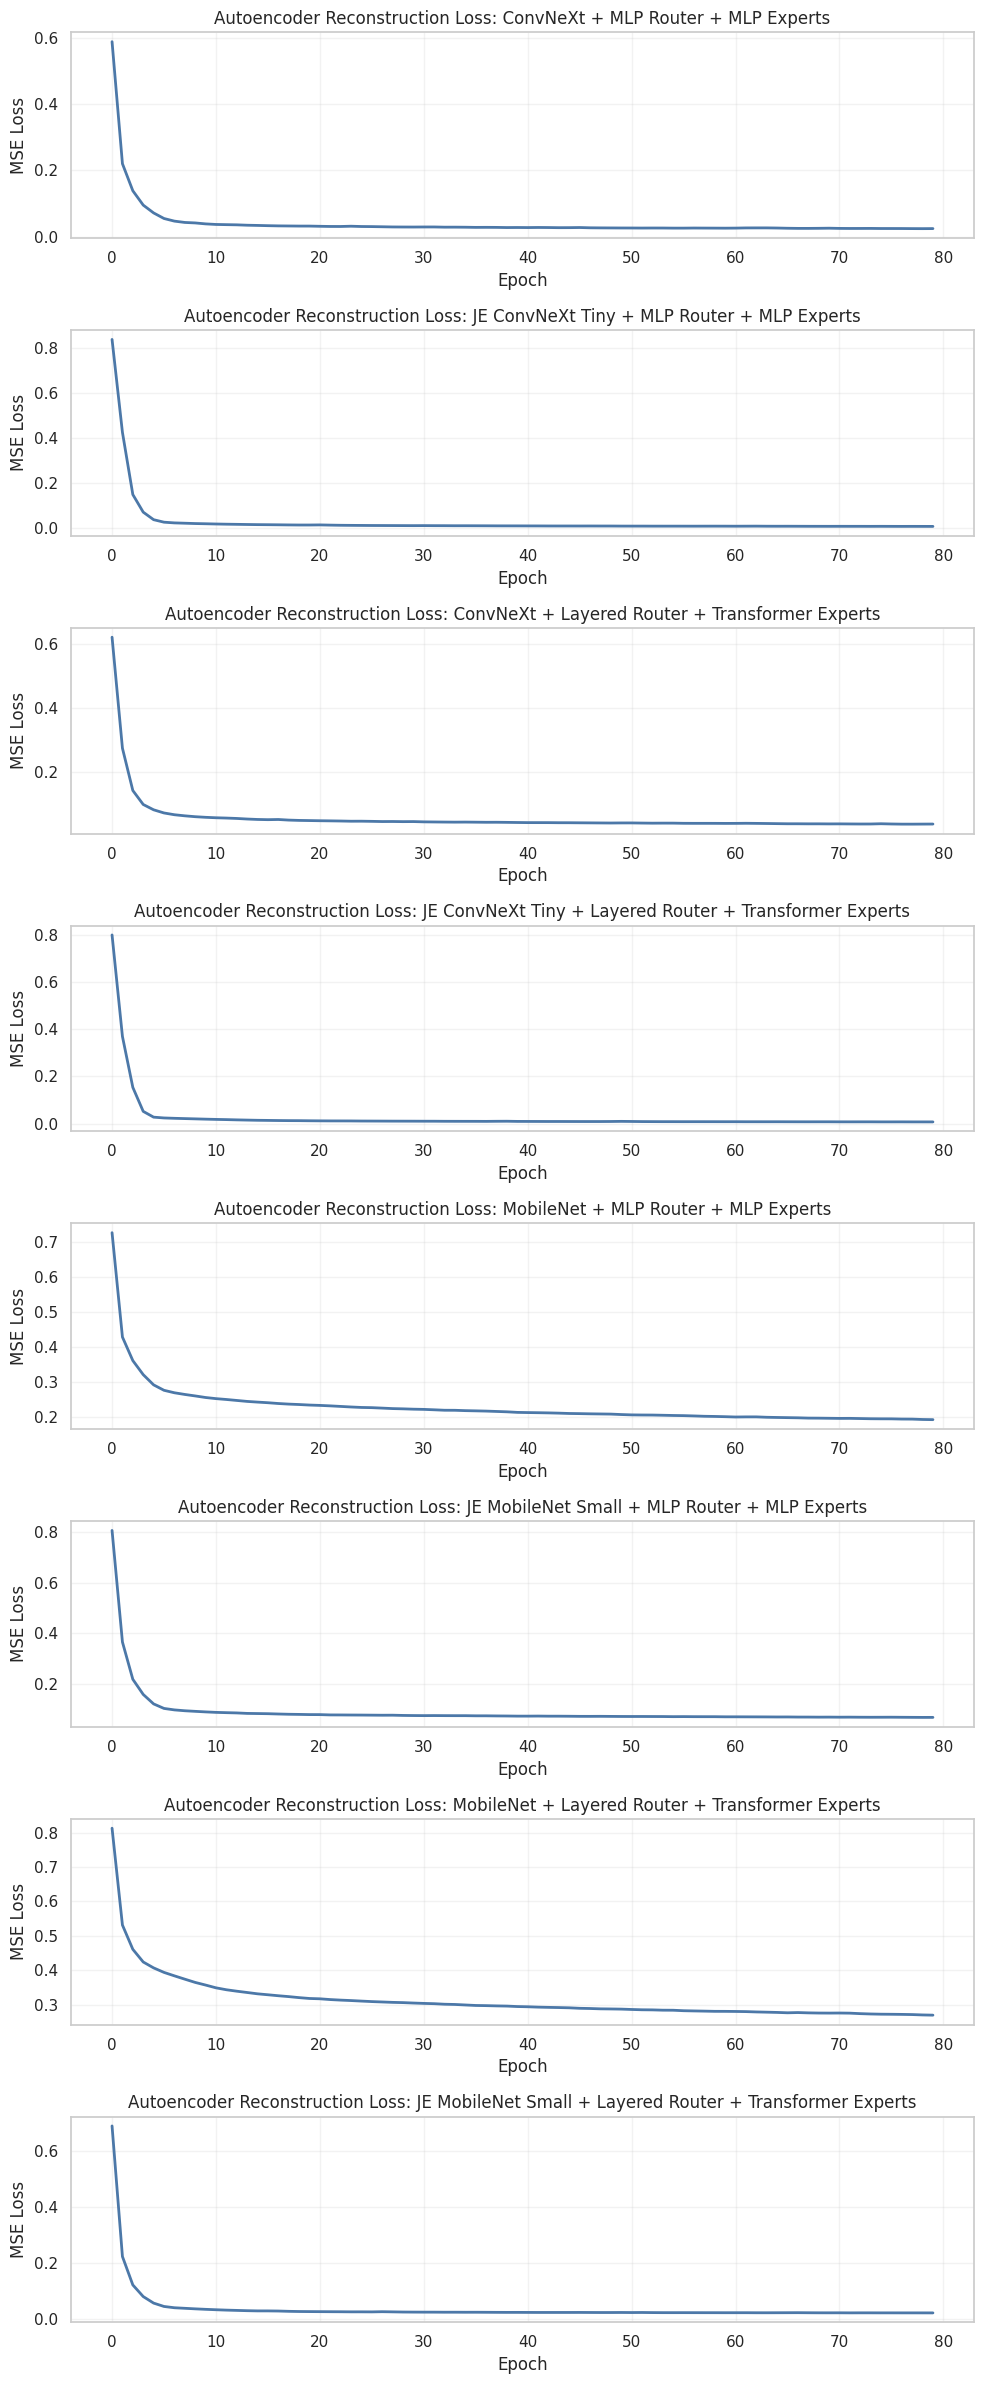

In [16]:
sns.set_theme(style='whitegrid')
class_palette = sns.color_palette('tab10', n_colors=len(class_mapping))

fig, axes = plt.subplots(len(projection_results), 1, figsize=(10, max(4, 3 * len(projection_results))), squeeze=False)
for ax, (model_name, result) in zip(axes[:, 0], projection_results.items()):
    ax.plot(result['loss_history'], color='#4C78A8', linewidth=2)
    ax.set_title(f'Autoencoder Reconstruction Loss: {model_name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [27]:
def compute_latent_axis_limits(latent_frame: pd.DataFrame, padding_ratio: float = 0.05):
    x_min = float(latent_frame['Latent X'].min())
    x_max = float(latent_frame['Latent X'].max())
    y_min = float(latent_frame['Latent Y'].min())
    y_max = float(latent_frame['Latent Y'].max())

    x_span = x_max - x_min
    y_span = y_max - y_min
    x_padding = max(x_span * padding_ratio, 1e-6)
    y_padding = max(y_span * padding_ratio, 1e-6)

    return (x_min - x_padding, x_max + x_padding), (y_min - y_padding, y_max + y_padding)

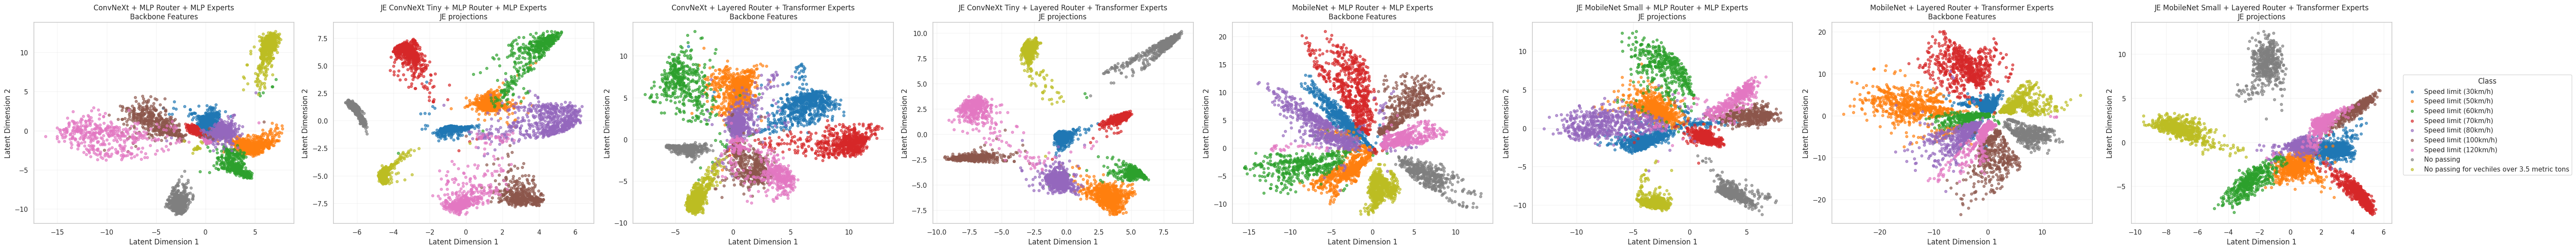

In [28]:
num_models = len(projection_results)
fig, axes = plt.subplots(1, num_models, figsize=(7 * num_models, 6), squeeze=False)

for ax, (model_name, result) in zip(axes[0], projection_results.items()):
    latent = result['latent']
    labels = result['labels']
    for class_id in sorted(np.unique(labels).tolist()):
        class_points = latent[labels == class_id]
        ax.scatter(
            class_points[:, 0],
            class_points[:, 1],
            s=18,
            alpha=0.65,
            color=class_palette[class_id],
            label=class_name_lookup.get(class_id, str(class_id)),
        )
    ax.set_title(f"{model_name}\n{result['feature_source']}")
    ax.set_xlabel('Latent Dimension 1')
    ax.set_ylabel('Latent Dimension 2')
    ax.grid(alpha=0.2)

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), title='Class')
plt.tight_layout()
plt.show()

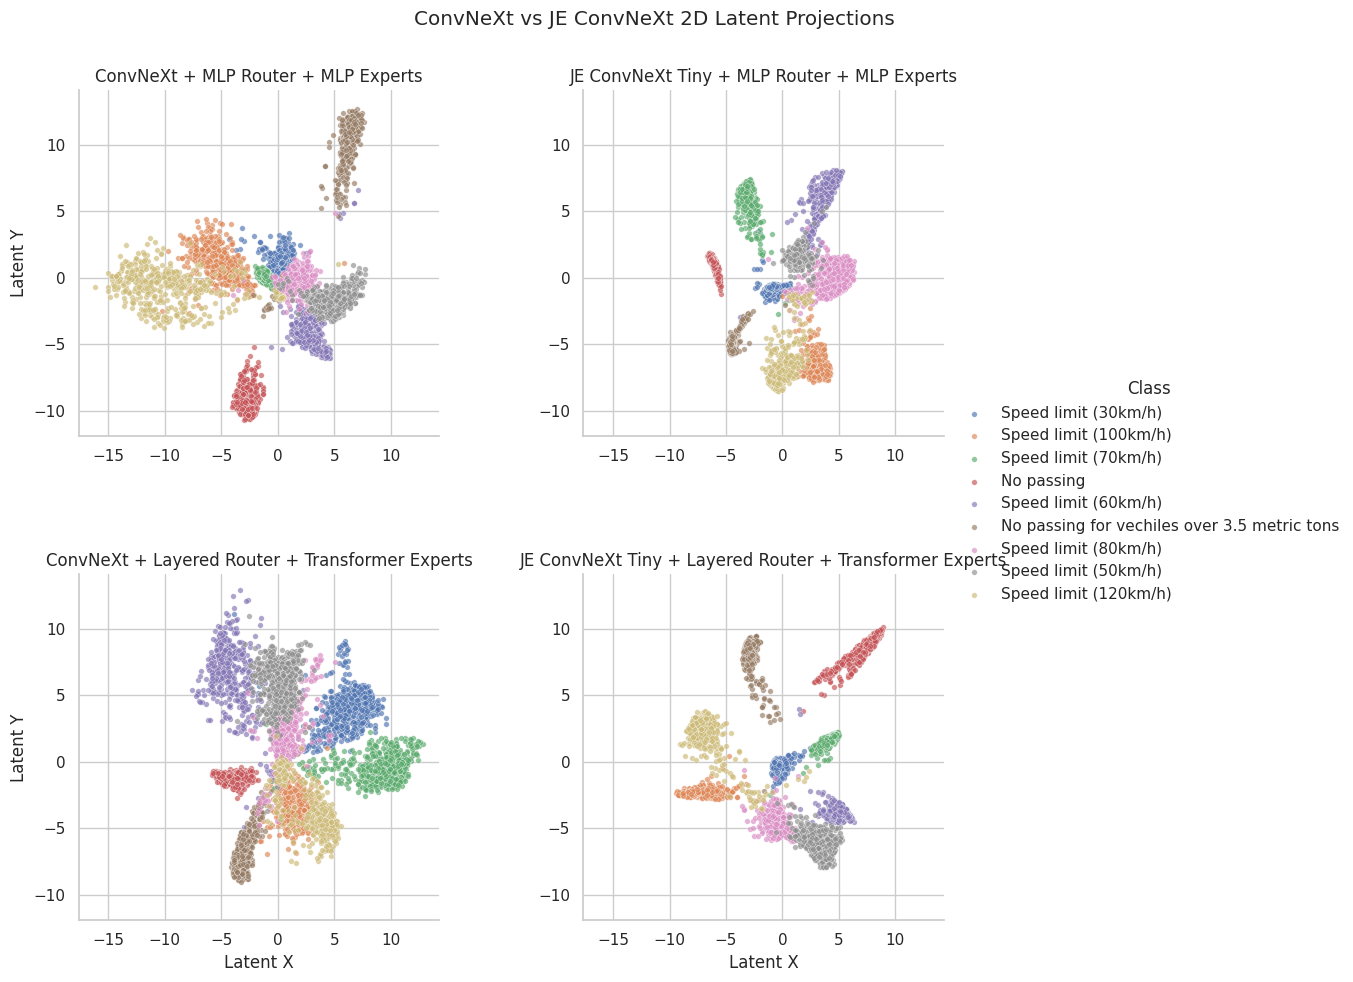

In [29]:
comparison_rows = []
for model_name, result in projection_results.items():
    latent = result['latent']
    labels = result['labels']
    for index in range(len(latent)):
        comparison_rows.append({
            'Model': model_name,
            'Backbone': result['backbone'],
            'Feature Source': result['feature_source'],
            'Class': class_name_lookup.get(int(labels[index]), str(int(labels[index]))),
            'Latent X': latent[index, 0],
            'Latent Y': latent[index, 1],
        })

latent_df = pd.DataFrame(comparison_rows)
convnext_df = latent_df[latent_df['Backbone'].isin(['ConvNeXt', 'JE ConvNeXt'])].copy()
convnext_xlim, convnext_ylim = compute_latent_axis_limits(convnext_df)
if not convnext_df.empty:
    g = sns.FacetGrid(convnext_df, col='Model', hue='Class', col_wrap=2, height=5, sharex=False, sharey=False)
    g.map_dataframe(sns.scatterplot, x='Latent X', y='Latent Y', alpha=0.65, s=16)
    g.set(xlim=convnext_xlim, ylim=convnext_ylim)
    g.add_legend()
    g.set_titles('{col_name}')
    g.figure.suptitle('ConvNeXt vs JE ConvNeXt 2D Latent Projections')
    g.figure.subplots_adjust(top=0.9, wspace=0.4, hspace=0.4)
    plt.show()
else:
    print('No ConvNeXt-family models were selected, so the focused ConvNeXt comparison plot was skipped.')

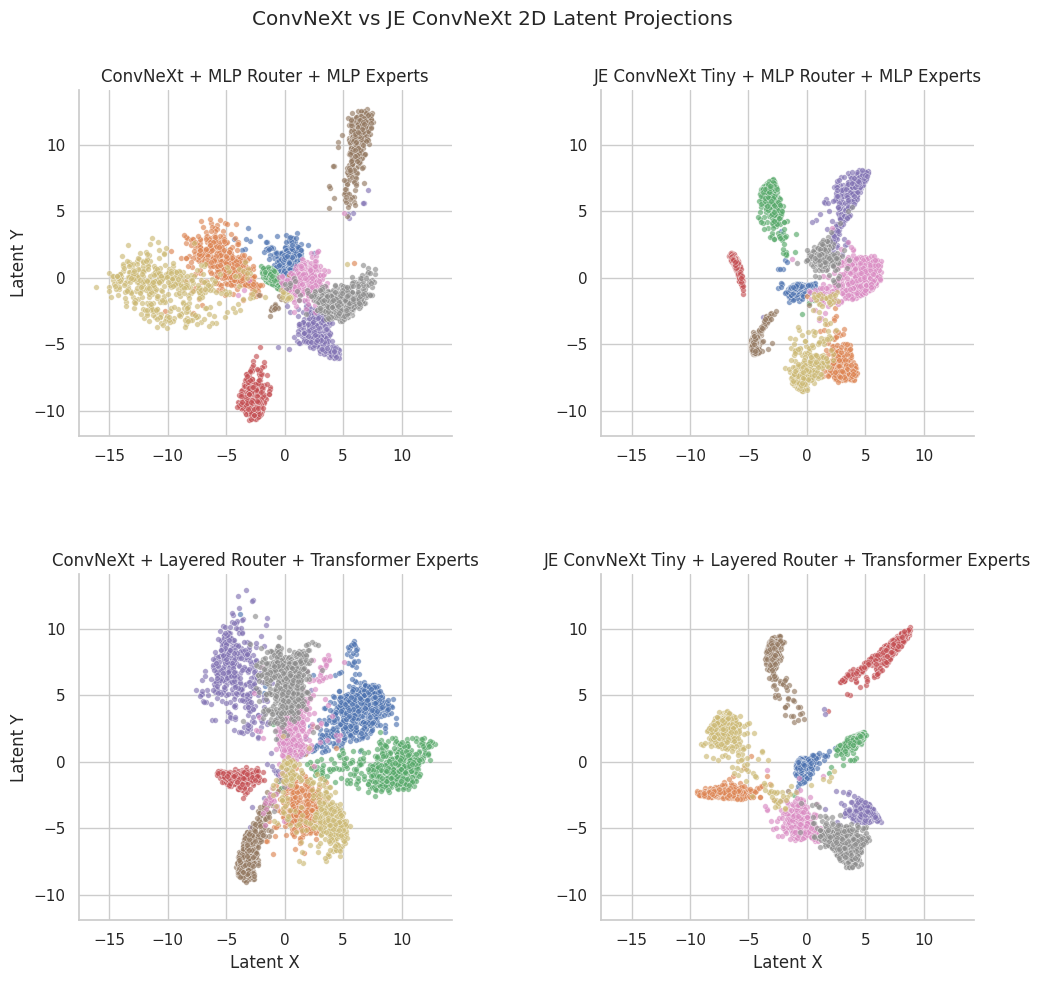

In [30]:
comparison_rows = []
for model_name, result in projection_results.items():
    latent = result['latent']
    labels = result['labels']
    for index in range(len(latent)):
        comparison_rows.append({
            'Model': model_name,
            'Backbone': result['backbone'],
            'Feature Source': result['feature_source'],
            'Class': class_name_lookup.get(int(labels[index]), str(int(labels[index]))),
            'Latent X': latent[index, 0],
            'Latent Y': latent[index, 1],
        })

latent_df = pd.DataFrame(comparison_rows)
convnext_df = latent_df[latent_df['Backbone'].isin(['ConvNeXt', 'JE ConvNeXt'])].copy()
if not convnext_df.empty:
    g = sns.FacetGrid(convnext_df, col='Model', hue='Class', col_wrap=2, height=5, sharex=False, sharey=False)
    g.map_dataframe(sns.scatterplot, x='Latent X', y='Latent Y', alpha=0.65, s=16)
    g.set(xlim=convnext_xlim, ylim=convnext_ylim)
    g.set_titles('{col_name}')
    g.figure.suptitle('ConvNeXt vs JE ConvNeXt 2D Latent Projections')
    g.figure.subplots_adjust(top=0.9, wspace=0.4, hspace=0.4)
    plt.show()
else:
    print('No ConvNeXt-family models were selected, so the focused ConvNeXt comparison plot was skipped.')

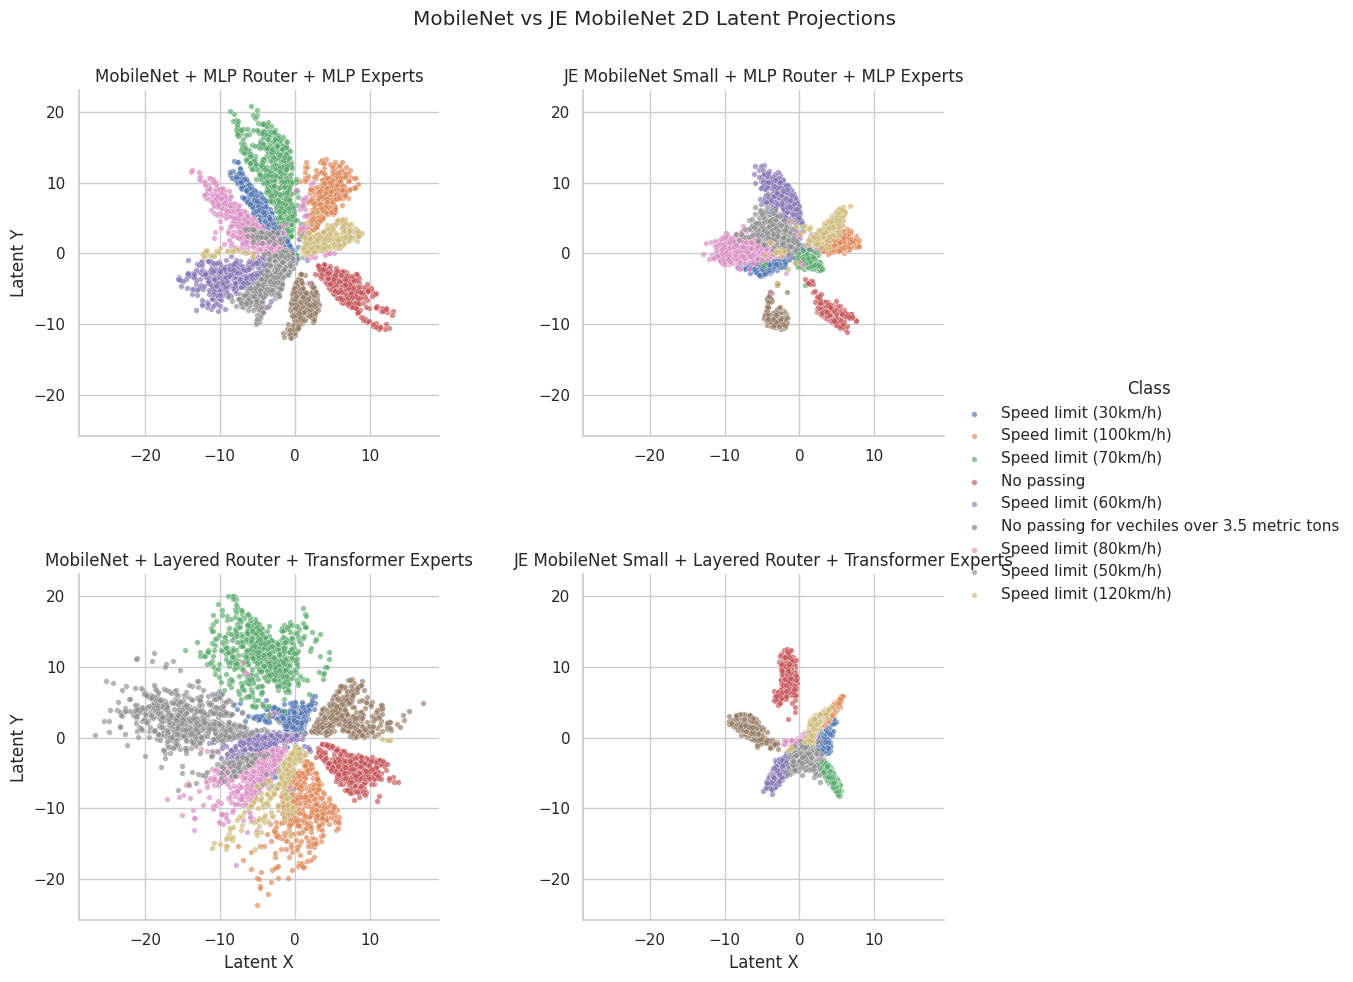

In [31]:
comparison_rows = []
for model_name, result in projection_results.items():
    latent = result['latent']
    labels = result['labels']
    for index in range(len(latent)):
        comparison_rows.append({
            'Model': model_name,
            'Backbone': result['backbone'],
            'Feature Source': result['feature_source'],
            'Class': class_name_lookup.get(int(labels[index]), str(int(labels[index]))),
            'Latent X': latent[index, 0],
            'Latent Y': latent[index, 1],
        })

latent_df = pd.DataFrame(comparison_rows)
mobilenet_df = latent_df[latent_df['Backbone'].isin(['MobileNet', 'JE MobileNet'])].copy()
mobilenet_xlim, mobilenet_ylim = compute_latent_axis_limits(mobilenet_df)
if not mobilenet_df.empty:
    g = sns.FacetGrid(mobilenet_df, col='Model', hue='Class', col_wrap=2, height=5, sharex=False, sharey=False)
    g.map_dataframe(sns.scatterplot, x='Latent X', y='Latent Y', alpha=0.65, s=16)
    g.set(xlim=mobilenet_xlim, ylim=mobilenet_ylim)
    g.add_legend()
    g.set_titles('{col_name}')
    g.figure.suptitle('MobileNet vs JE MobileNet 2D Latent Projections')
    g.figure.subplots_adjust(top=0.9, wspace=0.4, hspace=0.4)
    plt.show()
else:
    print('No MobileNet-family models were selected, so the focused MobileNet comparison plot was skipped.')

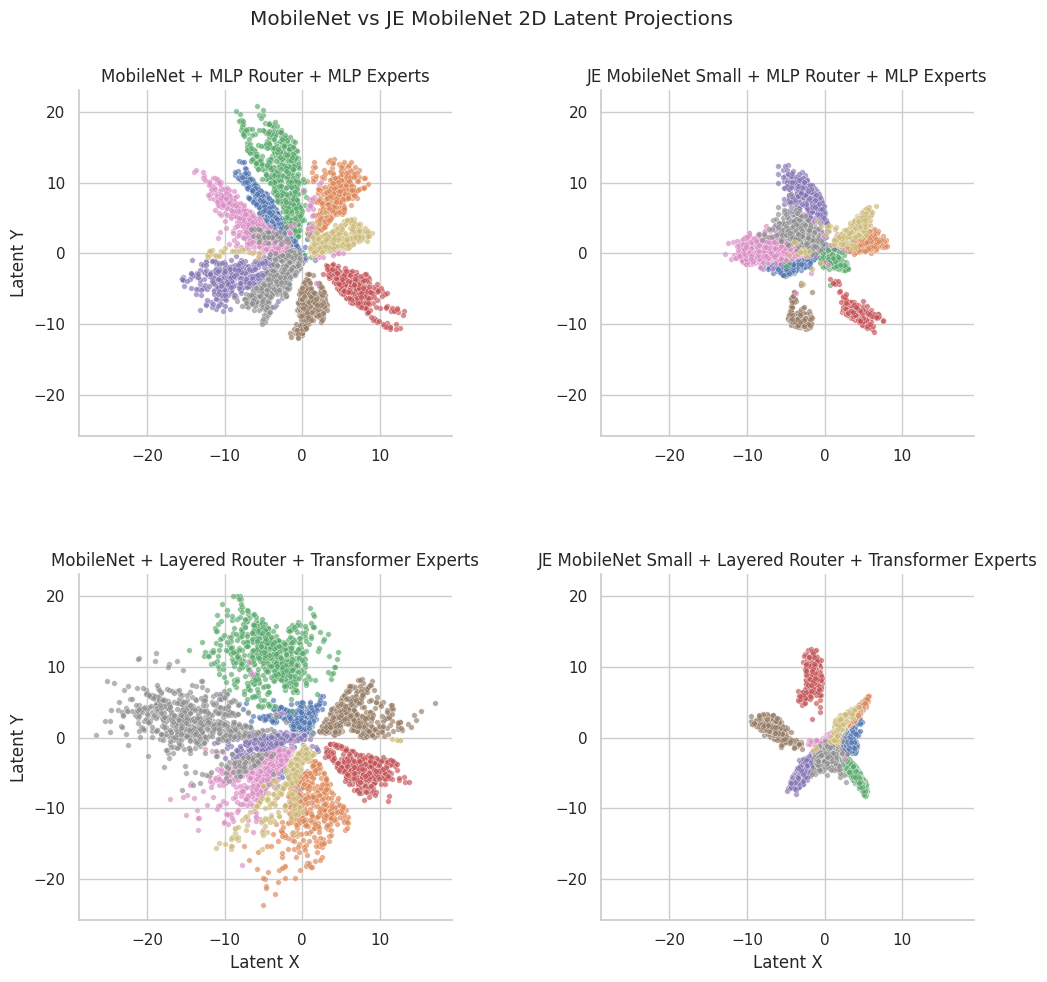

In [32]:
comparison_rows = []
for model_name, result in projection_results.items():
    latent = result['latent']
    labels = result['labels']
    for index in range(len(latent)):
        comparison_rows.append({
            'Model': model_name,
            'Backbone': result['backbone'],
            'Feature Source': result['feature_source'],
            'Class': class_name_lookup.get(int(labels[index]), str(int(labels[index]))),
            'Latent X': latent[index, 0],
            'Latent Y': latent[index, 1],
        })

latent_df = pd.DataFrame(comparison_rows)
mobilenet_df = latent_df[latent_df['Backbone'].isin(['MobileNet', 'JE MobileNet'])].copy()
if not mobilenet_df.empty:
    g = sns.FacetGrid(mobilenet_df, col='Model', hue='Class', col_wrap=2, height=5, sharex=False, sharey=False)
    g.map_dataframe(sns.scatterplot, x='Latent X', y='Latent Y', alpha=0.65, s=16)
    g.set(xlim=mobilenet_xlim, ylim=mobilenet_ylim)
    g.set_titles('{col_name}')
    g.figure.suptitle('MobileNet vs JE MobileNet 2D Latent Projections')
    g.figure.subplots_adjust(top=0.9, wspace=0.4, hspace=0.4)
    plt.show()
else:
    print('No MobileNet-family models were selected, so the focused MobileNet comparison plot was skipped.')

In [33]:
def build_expert_usage_overlay_df(checkpoint_paths, projection_lookup):
    overlay_frames = []

    for checkpoint_path in checkpoint_paths:
        model_name = extract_model_name(checkpoint_path)
        if model_name not in projection_lookup:
            continue

        model_instance = build_model_from_name(model_name)
        wrapper = CILComputerVisionModel.load(model_instance, filename=str(checkpoint_path), device=device)
        model = wrapper.model.to(device)
        model.eval()

        routing_rows = []
        with torch.no_grad():
            for images, labels, paths in analysis_dataloader:
                if hasattr(model, 'reset_routing_state'):
                    model.reset_routing_state()
                images = torch.stack(images).to(device)
                _ = model(images)

                topk_indices = getattr(model, '_last_topk_indices', None)
                router_probs = getattr(model, '_last_router_probs', None)
                if topk_indices is None or router_probs is None:
                    continue

                topk_indices = topk_indices.detach().cpu().numpy()
                router_probs = router_probs.detach().cpu().numpy()
                batch_labels = [int(label['label']) for label in labels]

                for batch_index, sample_path in enumerate(paths):
                    primary_expert = int(topk_indices[batch_index, 0])
                    routing_rows.append({
                        'Path': sample_path,
                        'Primary Expert': primary_expert,
                        'Top-k Experts': ', '.join(f'E{int(expert_idx)}' for expert_idx in topk_indices[batch_index]),
                        'Primary Expert Prob': float(router_probs[batch_index, primary_expert]),
                        'Class': class_name_lookup.get(batch_labels[batch_index], str(batch_labels[batch_index])),
                    })

        routing_df = pd.DataFrame(routing_rows)
        projection_result = projection_lookup[model_name]
        target_paths = projection_result['paths']
        path_order = {path: index for index, path in enumerate(target_paths)}
        aligned_df = routing_df[routing_df['Path'].isin(path_order)].copy()
        aligned_df['Projection Order'] = aligned_df['Path'].map(path_order)
        aligned_df = aligned_df.sort_values('Projection Order').reset_index(drop=True)

        if len(aligned_df) != len(projection_result['latent']):
            print(f'Skipping overlay for {model_name}: routed samples ({len(aligned_df)}) did not match latent samples ({len(projection_result[latent])}).')
            continue

        aligned_df['Model'] = model_name
        aligned_df['Latent X'] = projection_result['latent'][:, 0]
        aligned_df['Latent Y'] = projection_result['latent'][:, 1]
        aligned_df['Backbone'] = projection_result['backbone']
        aligned_df['Feature Source'] = projection_result['feature_source']
        overlay_frames.append(aligned_df)

    if not overlay_frames:
        return pd.DataFrame()

    return pd.concat(overlay_frames, ignore_index=True)

,Model,Primary Expert,Selections,Selection Rate
0,ConvNeXt + Layered Router + Transformer Experts,0,987,0.188000
1,ConvNeXt + Layered Router + Transformer Experts,1,145,0.027619
2,ConvNeXt + Layered Router + Transformer Experts,2,1821,0.346857
3,ConvNeXt + Layered Router + Transformer Experts,3,86,0.016381
4,ConvNeXt + Layered Router + Transformer Experts,4,792,0.150857
5,ConvNeXt + Layered Router + Transformer Experts,5,1419,0.270286
6,ConvNeXt + MLP Router + MLP Experts,0,1544,0.294095
7,ConvNeXt + MLP Router + MLP Experts,1,1049,0.199810
8,ConvNeXt + MLP Router + MLP Experts,2,285,0.054286
9,ConvNeXt + MLP Router + MLP Experts,3,41,0.007810


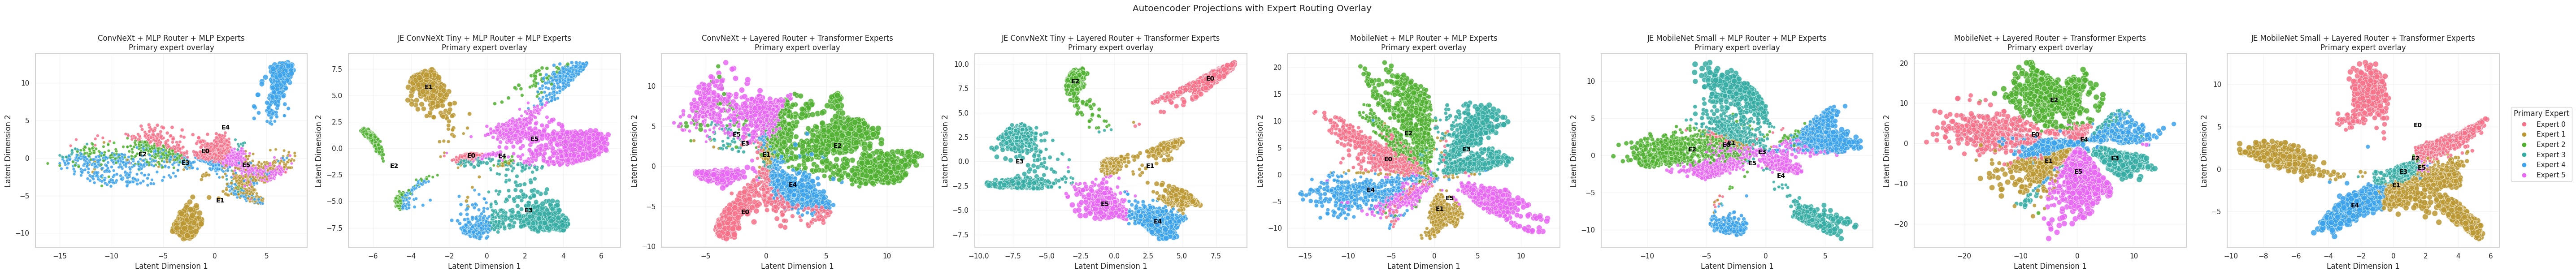

In [34]:
expert_overlay_df = build_expert_usage_overlay_df(selected_checkpoint_paths, projection_results)
if expert_overlay_df.empty:
    print('No expert-routing overlay data was available for the selected models.')
else:
    usage_summary = expert_overlay_df.groupby(['Model', 'Primary Expert']).size().rename('Selections').reset_index()
    usage_summary['Selection Rate'] = usage_summary.groupby('Model')['Selections'].transform(lambda counts: counts / counts.sum())
    display(usage_summary)

    expert_palette = sns.color_palette('husl', n_colors=NUM_EXPERTS)
    num_models = expert_overlay_df['Model'].nunique()
    fig, axes = plt.subplots(1, num_models, figsize=(7 * num_models, 6), squeeze=False)

    for ax, (model_name, model_df) in zip(axes[0], expert_overlay_df.groupby('Model', sort=False)):
        ax.scatter(
            model_df['Latent X'],
            model_df['Latent Y'],
            color='lightgray',
            s=10,
            alpha=0.20,
            linewidths=0,
        )
        sns.scatterplot(
            data=model_df,
            x='Latent X',
            y='Latent Y',
            hue='Primary Expert',
            size='Primary Expert Prob',
            palette=expert_palette,
            sizes=(20, 90),
            alpha=0.85,
            legend=False,
            ax=ax,
        )

        expert_centers = model_df.groupby('Primary Expert')[['Latent X', 'Latent Y']].mean().reset_index()
        for row in expert_centers.itertuples(index=False):
            ax.text(row[1], row[2], f'E{int(row[0])}', fontsize=10, weight='bold', ha='center', va='center', color='black')

        ax.set_title(f'{model_name}\nPrimary expert overlay')
        ax.set_xlabel('Latent Dimension 1')
        ax.set_ylabel('Latent Dimension 2')
        ax.grid(alpha=0.2)

    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], marker='o', color='w', label=f'Expert {expert_idx}', markerfacecolor=expert_palette[expert_idx], markersize=8)
        for expert_idx in range(NUM_EXPERTS)
    ]
    fig.legend(legend_handles, [handle.get_label() for handle in legend_handles], loc='center left', bbox_to_anchor=(1.0, 0.5), title='Primary Expert')
    fig.suptitle('Autoencoder Projections with Expert Routing Overlay', y=1.02)
    plt.tight_layout()
    plt.show()

### ConvNeXt Expert Routing Overlay

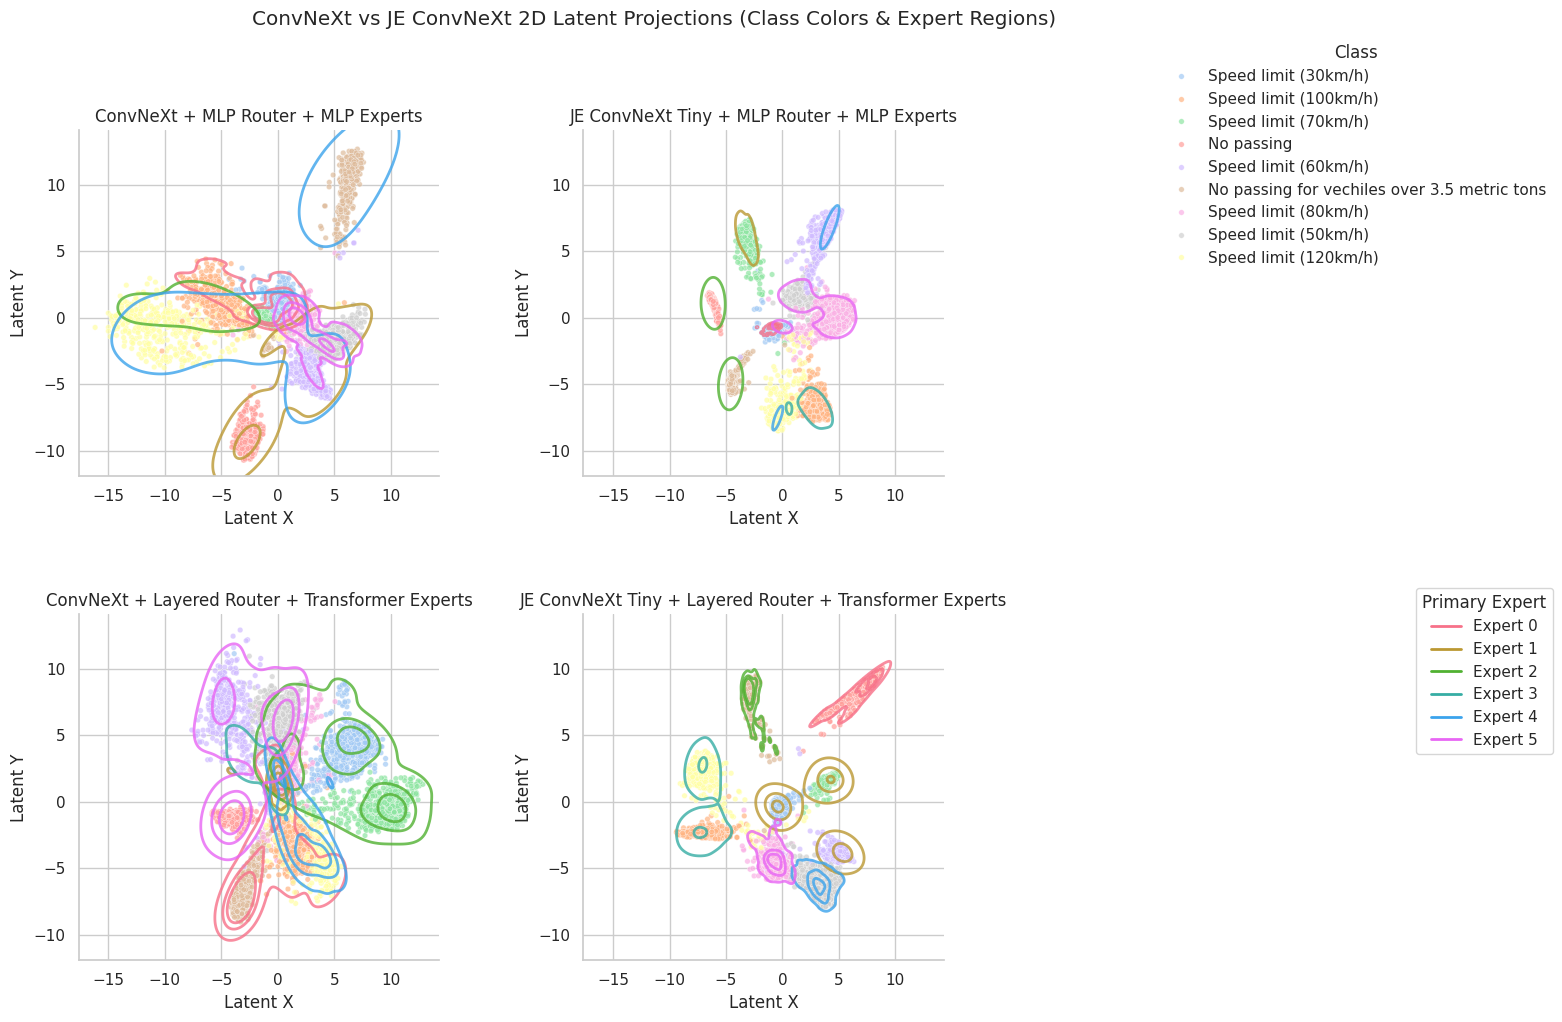

In [35]:
from matplotlib.lines import Line2D

convnext_expert_df = expert_overlay_df[expert_overlay_df['Backbone'].isin(['ConvNeXt', 'JE ConvNeXt'])].copy()

if not convnext_expert_df.empty:
    g = sns.FacetGrid(convnext_expert_df, col='Model', col_wrap=2, height=5, sharex=False, sharey=False)

    subtle_class_palette = sns.color_palette("pastel", n_colors=len(class_mapping))

    g.map_dataframe(sns.scatterplot, x='Latent X', y='Latent Y', hue='Class', alpha=0.7, s=16, palette=subtle_class_palette)

    for ax, (model_name, model_df) in zip(g.axes.flat, convnext_expert_df.groupby('Model', sort=False)):
        sns.kdeplot(
            data=model_df,
            x='Latent X',
            y='Latent Y',
            hue='Primary Expert',
            palette=expert_palette,
            levels=4,
            alpha=0.8,
            linewidths=2.0,
            ax=ax,
            legend=False
        )

    g.add_legend(title='Class', loc='upper right', bbox_to_anchor=(1.15, 1.0))
    expert_handles = [Line2D([0], [0], color=expert_palette[i], lw=2, label=f'Expert {i}') for i in range(NUM_EXPERTS)]
    g.figure.legend(handles=expert_handles, title='Primary Expert', loc='upper right', bbox_to_anchor=(1.15, 0.45))
    g.set(xlim=convnext_xlim, ylim=convnext_ylim)
    g.set_titles('{col_name}')
    g.figure.suptitle('ConvNeXt vs JE ConvNeXt 2D Latent Projections (Class Colors & Expert Regions)', y=1.02)
    g.figure.subplots_adjust(top=0.9, wspace=0.4, hspace=0.4)
    plt.show()
else:
    print('No ConvNeXt-family models were selected, so the focused ConvNeXt expert overlay plot was skipped.')

### MobileNet Expert Routing Overlay

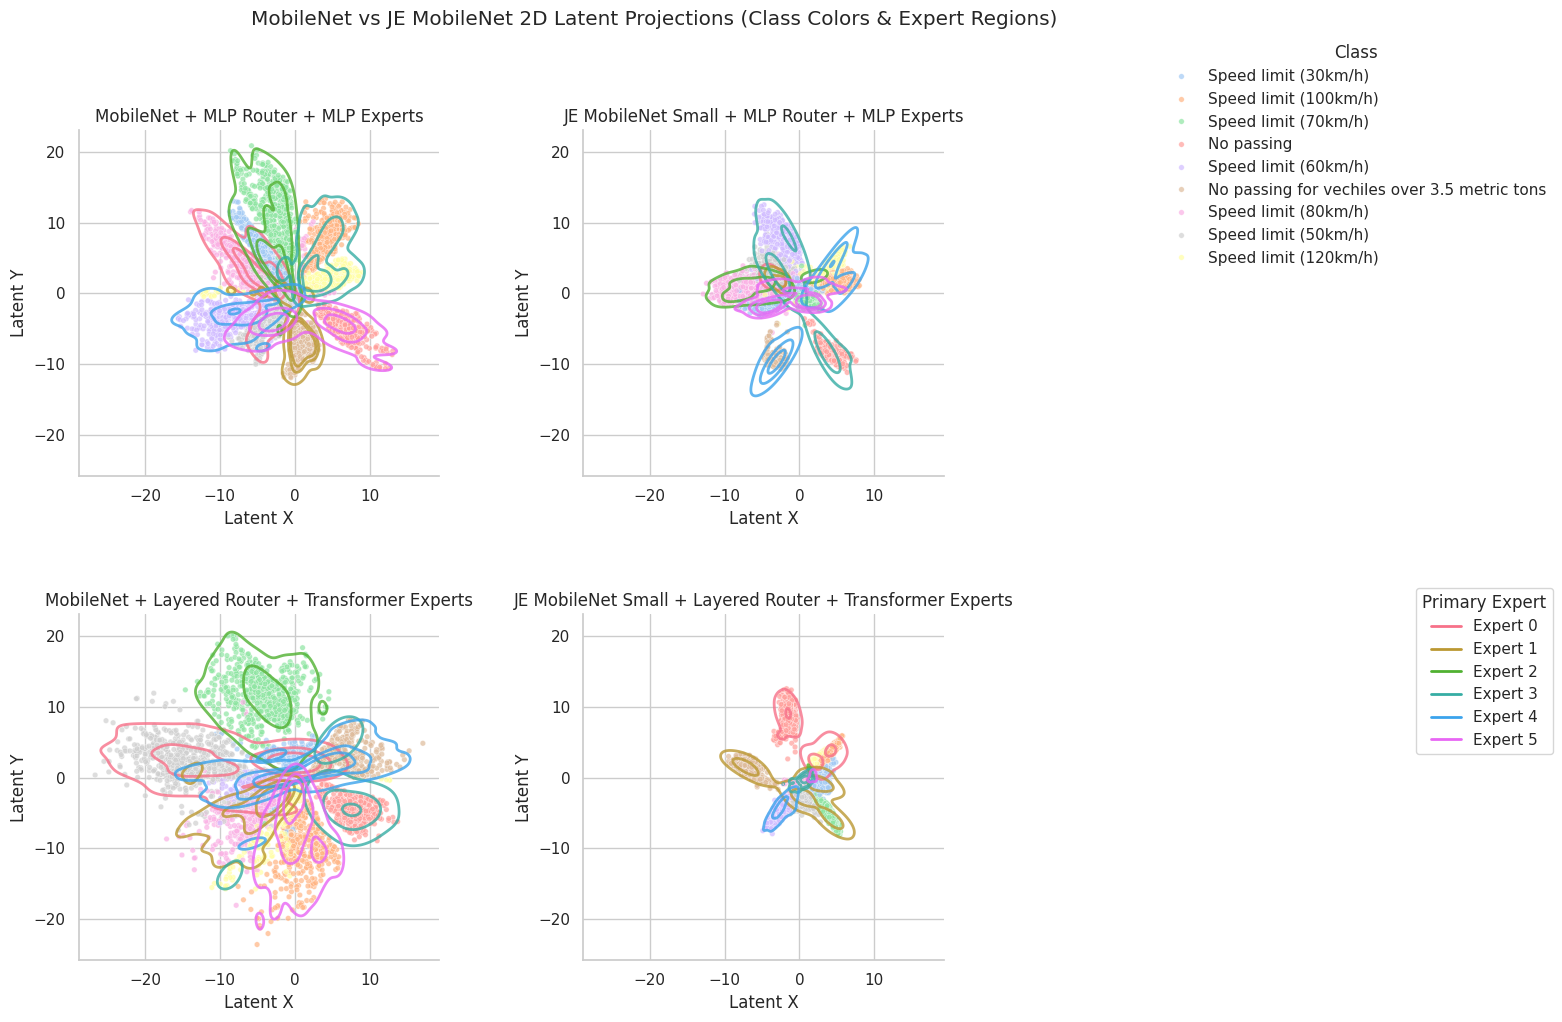

In [36]:
from matplotlib.lines import Line2D

mobilenet_expert_df = expert_overlay_df[expert_overlay_df['Backbone'].isin(['MobileNet', 'JE MobileNet'])].copy()

if not mobilenet_expert_df.empty:
    g = sns.FacetGrid(mobilenet_expert_df, col='Model', col_wrap=2, height=5, sharex=False, sharey=False)

    subtle_class_palette = sns.color_palette("pastel", n_colors=len(class_mapping))

    g.map_dataframe(sns.scatterplot, x='Latent X', y='Latent Y', hue='Class', alpha=0.7, s=16, palette=subtle_class_palette)

    for ax, (model_name, model_df) in zip(g.axes.flat, mobilenet_expert_df.groupby('Model', sort=False)):
        sns.kdeplot(
            data=model_df,
            x='Latent X',
            y='Latent Y',
            hue='Primary Expert',
            palette=expert_palette,
            levels=4,
            alpha=0.8,
            linewidths=2.0,
            ax=ax,
            legend=False
        )

    g.add_legend(title='Class', loc='upper right', bbox_to_anchor=(1.15, 1.0))
    expert_handles = [Line2D([0], [0], color=expert_palette[i], lw=2, label=f'Expert {i}') for i in range(NUM_EXPERTS)]
    g.figure.legend(handles=expert_handles, title='Primary Expert', loc='upper right', bbox_to_anchor=(1.15, 0.45))
    g.set(xlim=mobilenet_xlim, ylim=mobilenet_ylim)
    g.set_titles('{col_name}')
    g.figure.suptitle('MobileNet vs JE MobileNet 2D Latent Projections (Class Colors & Expert Regions)', y=1.02)
    g.figure.subplots_adjust(top=0.9, wspace=0.4, hspace=0.4)
    plt.show()
else:
    print('No MobileNet-family models were selected, so the focused MobileNet expert overlay plot was skipped.')